# Phase 3 — External Data Enrichment

This notebook explores the four external datasets integrated with the LAPD crime data and analyzes cross-domain relationships.

**Datasets merged:**
| # | Source | Coverage | Granularity |
|---|--------|----------|-------------|
| 1 | LAPD Division boundaries (convex hull) | 21 divisions | polygon |
| 2 | Census TIGER tract boundaries | 2,495 LA County tracts | polygon |
| 3 | Open-Meteo historical weather | 2020–2024 (1,827 days) | daily |
| 4 | BLS unemployment (LA-Long Beach MSA) | 2020–2024 (60 months) | monthly |

**Enriched file:** `data/processed/lapd_enriched.parquet` — 1,004,894 rows × 73 columns

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
EXT    = ROOT / 'data' / 'external'
FIGDIR = ROOT / 'outputs' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
BG      = '#0f1117'
SURFACE = '#1a1d27'
BLUE    = '#4f8ef7'
RED     = '#e05252'
GREEN   = '#3ecf8e'
ORANGE  = '#e0883a'
PURPLE  = '#7c5cbf'
YELLOW  = '#e0c066'
CYAN    = '#60c9d4'
MUTED   = '#7b82a0'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': SURFACE,
    'axes.edgecolor': MUTED, 'axes.labelcolor': 'white',
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': 'white', 'grid.color': '#2a2d3a',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlepad': 12,
})

def save(name):
    plt.savefig(FIGDIR / f'{name}.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

print('Libraries loaded.')

Libraries loaded.


## 0. Load Data

In [2]:
df = pd.read_parquet(PROC / 'lapd_enriched.parquet')
df['date_occ'] = pd.to_datetime(df['date_occ'])
df['year_month'] = df['date_occ'].dt.to_period('M')

divisions = gpd.read_file(EXT / 'lapd_divisions.geojson')
tracts    = gpd.read_file(EXT / 'census_tracts_la.geojson')
weather   = pd.read_csv(EXT / 'weather_la_2020_2024.csv', parse_dates=['date'])
unemp     = pd.read_csv(EXT / 'unemployment_la_2020_2024.csv')

print(f'Crime enriched : {len(df):,} rows x {df.shape[1]} cols')
print(f'Divisions      : {len(divisions)} polygons')
print(f'Census tracts  : {len(tracts):,} polygons')
print(f'Weather days   : {len(weather):,}')
print(f'Unemployment   : {len(unemp)} months')
print(f'\nNew columns: {[c for c in df.columns if c not in ["DR_NO","date_occ","LAT","LON"]][-15:]}')

Crime enriched : 1,004,894 rows x 74 cols
Divisions      : 21 polygons
Census tracts  : 2,495 polygons
Weather days   : 1,827
Unemployment   : 60 months

New columns: ['temp_max_f', 'temp_min_f', 'temp_avg_f', 'precip_in', 'wind_max_mph', 'is_hot_day', 'is_rainy', 'unemp_rate_pct', 'GEOID', 'pop_total', 'median_hh_income', 'poverty_rate', 'owner_occ_rate', 'unemployment_rate_ct', 'year_month']


---
## 1. Geographic Coverage

### 1A — LAPD Division Map with Crime Density

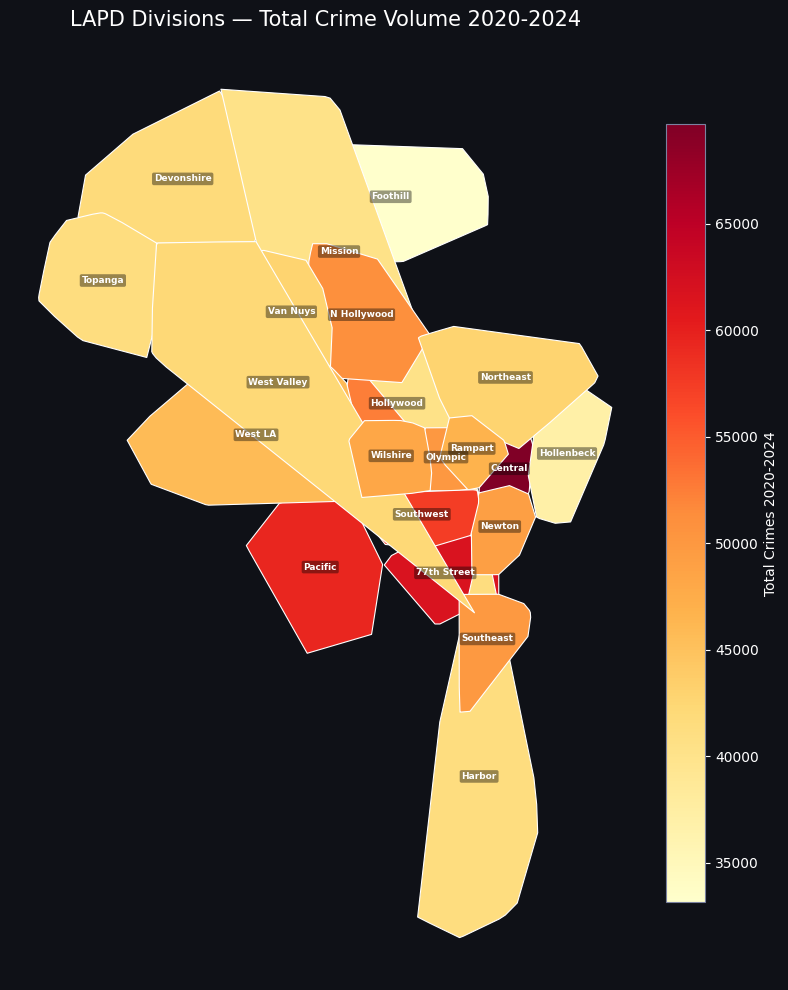

In [3]:
# Crime count per division
div_counts = df.groupby('AREA NAME').size().reset_index(name='crime_count')
div_plot   = divisions.merge(div_counts, left_on='area name', right_on='AREA NAME', how='left')

fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
ax.set_facecolor(SURFACE)

# Choropleth
vmin = div_plot['crime_count'].min()
vmax = div_plot['crime_count'].max()
norm = Normalize(vmin=vmin, vmax=vmax)

div_plot.plot(column='crime_count', ax=ax, cmap='YlOrRd',
              edgecolor='white', linewidth=0.8,
              missing_kwds={'color': MUTED})

# Division labels
for _, row in div_plot.iterrows():
    if row.geometry and not row.geometry.is_empty:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        name = str(row.get('area name', '')).strip()
        ax.annotate(name, (cx, cy), ha='center', fontsize=6.5,
                    color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.4, ec='none'))

sm = ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Total Crimes 2020-2024', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.ax.set_facecolor(BG)

ax.set_title('LAPD Divisions — Total Crime Volume 2020-2024', fontsize=15, color='white', pad=15)
ax.set_axis_off()
fig.tight_layout()
save('p3_01_division_map')

**Findings:**
- Central Division consistently shows the highest crime density (skid row, downtown)
- Topanga and Foothill show lower volumes, reflecting lower-density residential areas
- The convex-hull boundaries are approximate — overlaps at edges are an artifact of the construction method

### 1B — Crime Density by Census Tract

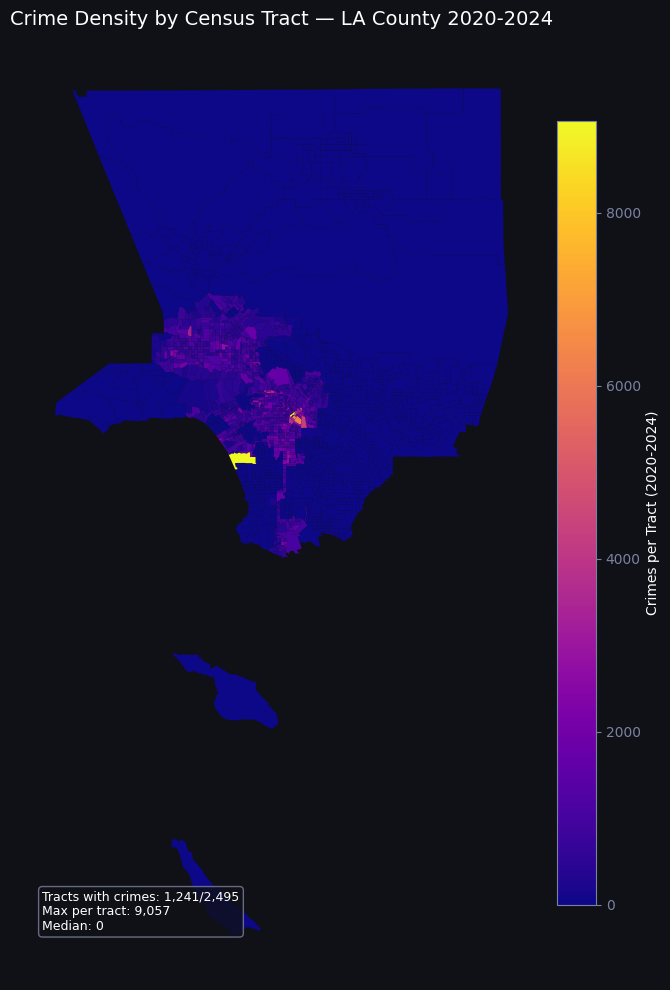

In [4]:
# Crimes per tract
tract_counts = df[df['GEOID'].notna()].groupby('GEOID').size().reset_index(name='crime_count')
tracts_plot  = tracts.merge(tract_counts, on='GEOID', how='left')
tracts_plot['crime_count'] = tracts_plot['crime_count'].fillna(0)

fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
ax.set_facecolor(SURFACE)

tracts_plot.plot(column='crime_count', ax=ax, cmap='plasma',
                 edgecolor='none', linewidth=0,
                 legend=True,
                 legend_kwds={'label': 'Crimes per Tract (2020-2024)',
                              'orientation': 'vertical',
                              'fraction': 0.03, 'pad': 0.02})

ax.set_title('Crime Density by Census Tract — LA County 2020-2024', fontsize=14, color='white', pad=15)
ax.set_axis_off()

# Stats annotation
top5 = tracts_plot.nlargest(5, 'crime_count')[['GEOID', 'crime_count']]
stats_txt = f'Tracts with crimes: {(tracts_plot["crime_count"]>0).sum():,}/{len(tracts_plot):,}\n'
stats_txt += f'Max per tract: {tracts_plot["crime_count"].max():,.0f}\n'
stats_txt += f'Median: {tracts_plot["crime_count"].median():.0f}'
ax.text(0.02, 0.05, stats_txt, transform=ax.transAxes,
        fontsize=9, color='white', va='bottom',
        bbox=dict(boxstyle='round', fc=BG, ec=MUTED, alpha=0.8))

fig.tight_layout()
save('p3_02_tract_density_map')

---
## 2. Weather Analysis

### 2A — Weather Profile 2020–2024

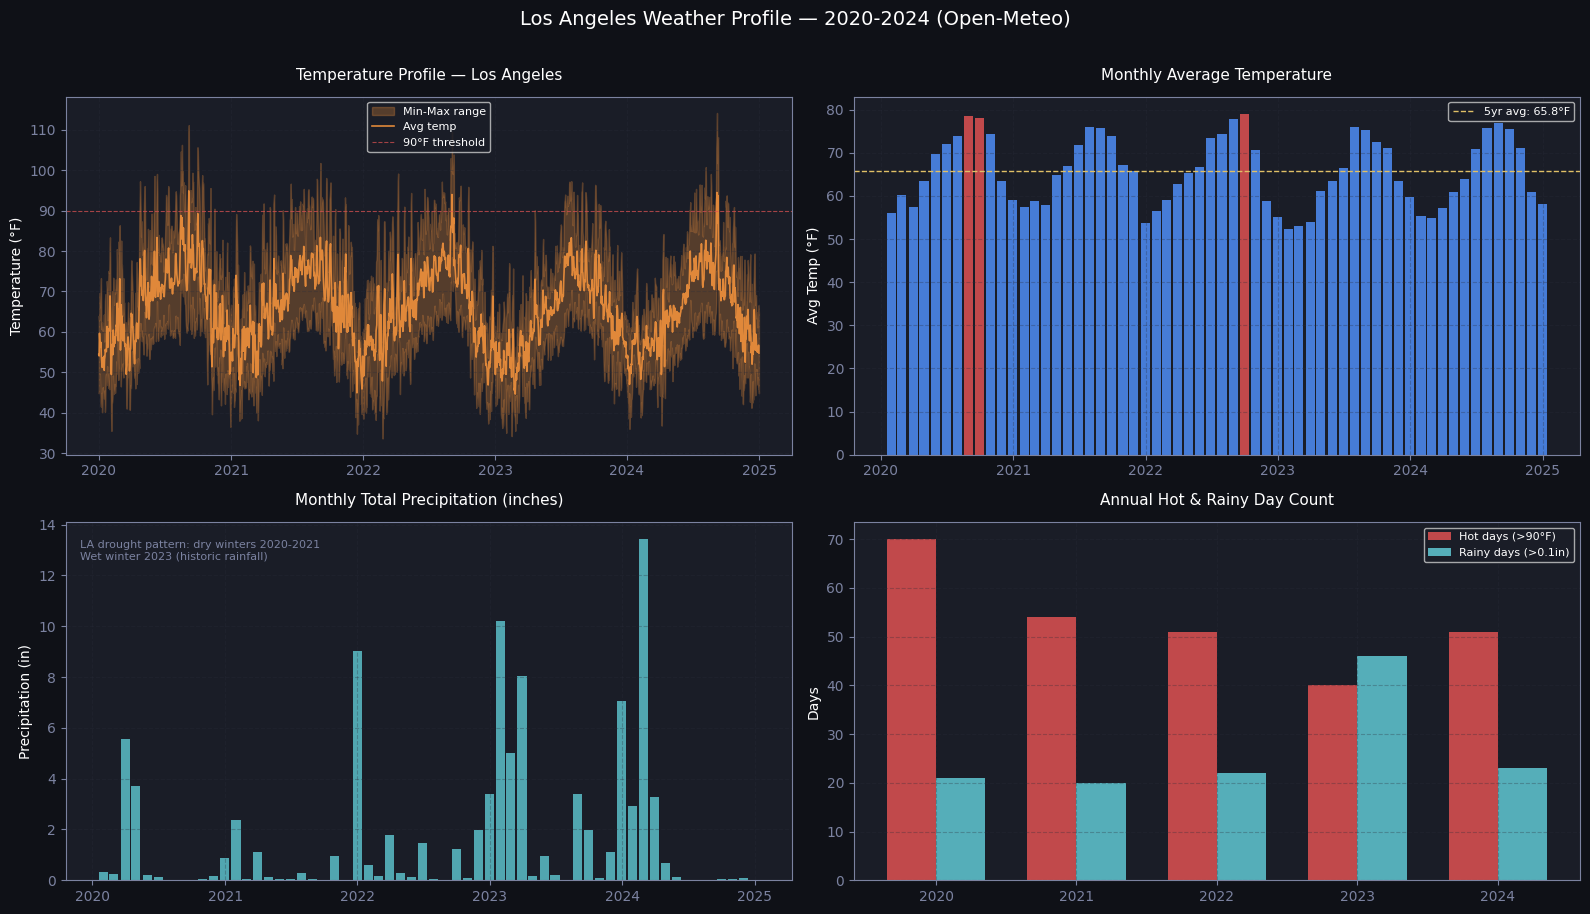

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), facecolor=BG)
axes = axes.flatten()

# Temperature range
ax = axes[0]
ax.fill_between(weather['date'], weather['temp_min_f'], weather['temp_max_f'],
                alpha=0.3, color=ORANGE, label='Min-Max range')
ax.plot(weather['date'], weather['temp_avg_f'], color=ORANGE, lw=1.2, label='Avg temp')
ax.axhline(90, color=RED, lw=0.8, ls='--', alpha=0.7, label='90°F threshold')
ax.set_title('Temperature Profile — Los Angeles', color='white', fontsize=11)
ax.set_ylabel('Temperature (°F)', color='white')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Monthly avg temperature
ax = axes[1]
monthly_w = weather.set_index('date').resample('ME').agg(
    temp_avg=('temp_avg_f', 'mean'),
    precip_sum=('precip_in', 'sum'),
    hot_days=('is_hot_day', 'sum'),
    rainy_days=('is_rainy', 'sum')
).reset_index()
bars = ax.bar(monthly_w['date'], monthly_w['temp_avg'],
              color=[RED if t >= 78 else BLUE for t in monthly_w['temp_avg']],
              alpha=0.85, width=25)
ax.set_title('Monthly Average Temperature', color='white', fontsize=11)
ax.set_ylabel('Avg Temp (°F)', color='white')
ax.axhline(monthly_w['temp_avg'].mean(), color=YELLOW, lw=1, ls='--', label=f'5yr avg: {monthly_w["temp_avg"].mean():.1f}°F')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Precipitation
ax = axes[2]
ax.bar(monthly_w['date'], monthly_w['precip_sum'],
       color=CYAN, alpha=0.8, width=25)
ax.set_title('Monthly Total Precipitation (inches)', color='white', fontsize=11)
ax.set_ylabel('Precipitation (in)', color='white')
ax.grid(True, alpha=0.3)
# Annotate dry/wet years
ax.text(0.02, 0.95, 'LA drought pattern: dry winters 2020-2021\nWet winter 2023 (historic rainfall)',
        transform=ax.transAxes, fontsize=8, color=MUTED, va='top')

# Hot days vs rainy days per year
ax = axes[3]
yearly_w = weather.copy()
yearly_w['year'] = weather['date'].dt.year
yw = yearly_w.groupby('year').agg(hot_days=('is_hot_day','sum'), rainy_days=('is_rainy','sum')).reset_index()
x = np.arange(len(yw))
w = 0.35
ax.bar(x - w/2, yw['hot_days'], width=w, color=RED, alpha=0.85, label='Hot days (>90°F)')
ax.bar(x + w/2, yw['rainy_days'], width=w, color=CYAN, alpha=0.85, label='Rainy days (>0.1in)')
ax.set_xticks(x)
ax.set_xticklabels(yw['year'])
ax.set_title('Annual Hot & Rainy Day Count', color='white', fontsize=11)
ax.set_ylabel('Days', color='white')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Los Angeles Weather Profile — 2020-2024 (Open-Meteo)', fontsize=14, color='white', y=1.01)
fig.tight_layout()
save('p3_03_weather_profile')

### 2B — Weather vs Daily Crime Volume

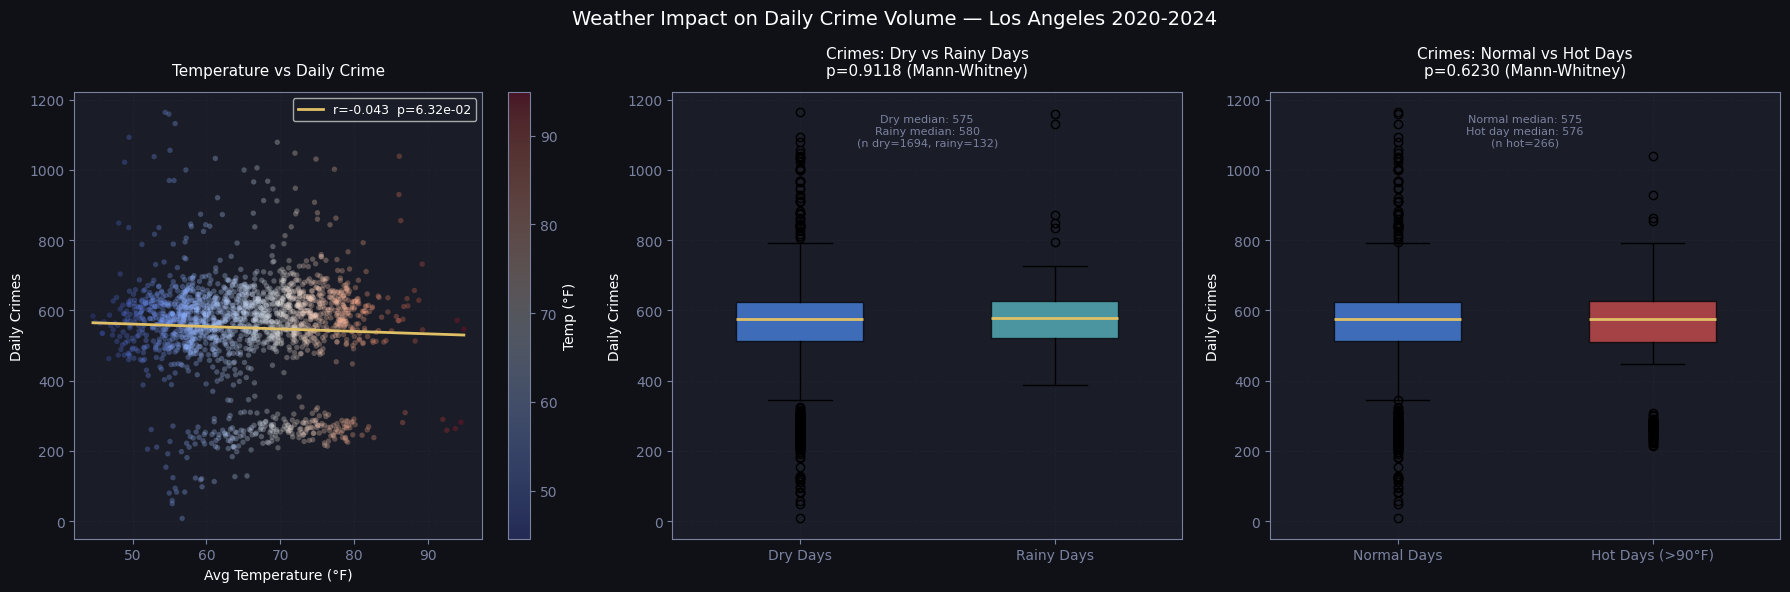

In [6]:
# Daily crime counts + weather
daily_crime = df.groupby('date_occ_date').size().reset_index(name='crimes')
daily_crime['date_occ_date'] = pd.to_datetime(daily_crime['date_occ_date'])
daily_w = daily_crime.merge(weather, left_on='date_occ_date', right_on='date', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)

# Scatter: temperature vs crimes
ax = axes[0]
sc = ax.scatter(daily_w['temp_avg_f'], daily_w['crimes'],
                alpha=0.3, s=15, c=daily_w['temp_avg_f'],
                cmap='coolwarm', edgecolors='none')
# Regression line
slope, intercept, r, p, _ = stats.linregress(daily_w['temp_avg_f'], daily_w['crimes'])
xline = np.linspace(daily_w['temp_avg_f'].min(), daily_w['temp_avg_f'].max(), 100)
ax.plot(xline, slope * xline + intercept, color=YELLOW, lw=2,
        label=f'r={r:.3f}  p={p:.2e}')
ax.set_xlabel('Avg Temperature (°F)')
ax.set_ylabel('Daily Crimes')
ax.set_title('Temperature vs Daily Crime', color='white', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Temp (°F)')

# Box: rainy vs non-rainy days
ax = axes[1]
rain_groups = [daily_w[daily_w['is_rainy'] == 0]['crimes'].values,
               daily_w[daily_w['is_rainy'] == 1]['crimes'].values]
bp = ax.boxplot(rain_groups, labels=['Dry Days', 'Rainy Days'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color=YELLOW, lw=2))
for patch, color in zip(bp['boxes'], [BLUE, CYAN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
n_dry  = (daily_w['is_rainy'] == 0).sum()
n_rain = (daily_w['is_rainy'] == 1).sum()
dry_med  = np.median(rain_groups[0])
rain_med = np.median(rain_groups[1])
_, pval = stats.mannwhitneyu(rain_groups[0], rain_groups[1], alternative='greater')
ax.set_title(f'Crimes: Dry vs Rainy Days\np={pval:.4f} (Mann-Whitney)', color='white', fontsize=11)
ax.set_ylabel('Daily Crimes')
ax.text(0.5, 0.95, f'Dry median: {dry_med:.0f}\nRainy median: {rain_med:.0f}\n(n dry={n_dry}, rainy={n_rain})',
        transform=ax.transAxes, ha='center', va='top', fontsize=8, color=MUTED)
ax.grid(True, alpha=0.3)

# Box: hot day vs normal day
ax = axes[2]
hot_groups = [daily_w[daily_w['is_hot_day'] == 0]['crimes'].values,
              daily_w[daily_w['is_hot_day'] == 1]['crimes'].values]
bp2 = ax.boxplot(hot_groups, labels=['Normal Days', 'Hot Days (>90°F)'],
                 patch_artist=True, widths=0.5,
                 medianprops=dict(color=YELLOW, lw=2))
for patch, color in zip(bp2['boxes'], [BLUE, RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
_, pval2 = stats.mannwhitneyu(hot_groups[1], hot_groups[0], alternative='greater')
normal_med = np.median(hot_groups[0])
hot_med    = np.median(hot_groups[1])
ax.set_title(f'Crimes: Normal vs Hot Days\np={pval2:.4f} (Mann-Whitney)', color='white', fontsize=11)
ax.set_ylabel('Daily Crimes')
ax.text(0.5, 0.95, f'Normal median: {normal_med:.0f}\nHot day median: {hot_med:.0f}\n(n hot={len(hot_groups[1])})',
        transform=ax.transAxes, ha='center', va='top', fontsize=8, color=MUTED)
ax.grid(True, alpha=0.3)

fig.suptitle('Weather Impact on Daily Crime Volume — Los Angeles 2020-2024', fontsize=14, color='white')
fig.tight_layout()
save('p3_04_weather_crime')

### 2C — Crime Categories by Temperature Bin

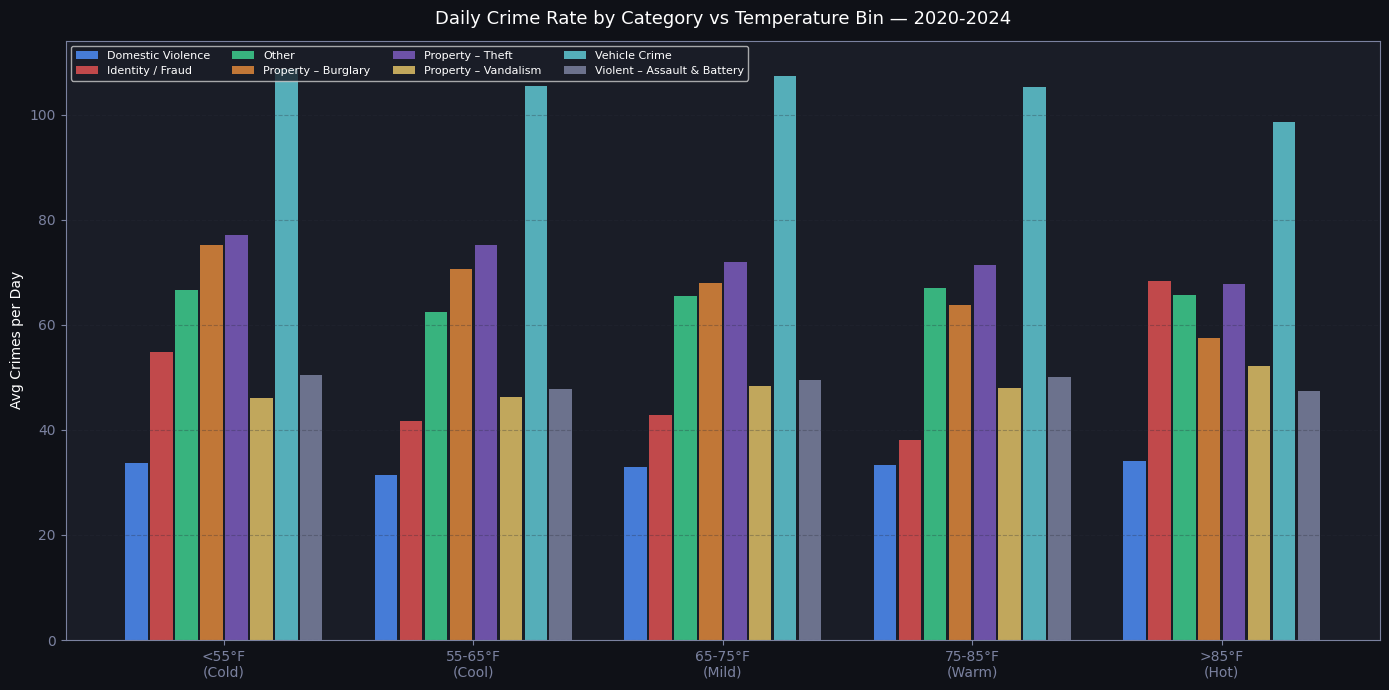

In [7]:
df['temp_bin'] = pd.cut(df['temp_avg_f'],
                        bins=[0, 55, 65, 75, 85, 120],
                        labels=['<55°F\n(Cold)', '55-65°F\n(Cool)', '65-75°F\n(Mild)',
                                '75-85°F\n(Warm)', '>85°F\n(Hot)'])

top_cats = df['crime_category'].value_counts().nlargest(8).index
cat_temp = (df[df['crime_category'].isin(top_cats)]
            .groupby(['temp_bin', 'crime_category'])
            .size()
            .unstack(fill_value=0))

# Normalize by number of days in each bin
days_per_bin = (df[['date_occ_date','temp_bin']].drop_duplicates()
                .groupby('temp_bin').size())
cat_temp_rate = cat_temp.div(days_per_bin, axis=0)

colors = [BLUE, RED, GREEN, ORANGE, PURPLE, YELLOW, CYAN, MUTED]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
x = np.arange(len(cat_temp_rate))
width = 0.1

for i, (cat, col) in enumerate(zip(cat_temp_rate.columns, colors)):
    ax.bar(x + i * width, cat_temp_rate[cat], width=width*0.9,
           label=cat, color=col, alpha=0.85)

ax.set_xticks(x + width * 3.5)
ax.set_xticklabels(cat_temp_rate.index, fontsize=10)
ax.set_ylabel('Avg Crimes per Day')
ax.set_title('Daily Crime Rate by Category vs Temperature Bin — 2020-2024', color='white', fontsize=13)
ax.legend(fontsize=8, ncol=4, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
save('p3_05_category_temp')

---
## 3. Unemployment Analysis

### 3A — Unemployment Rate Timeline

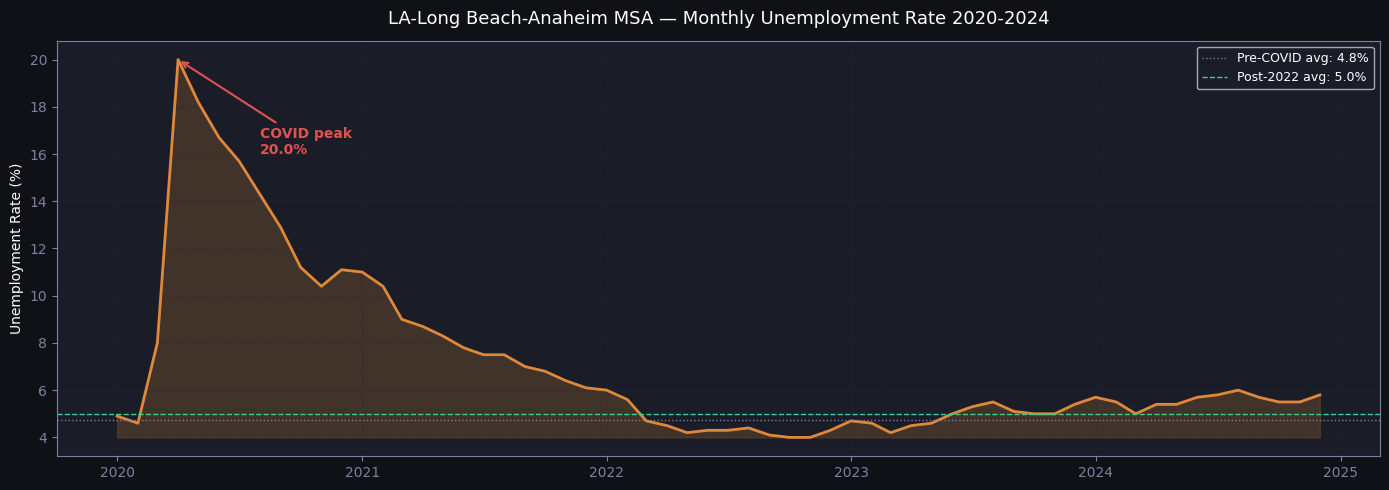

In [8]:
unemp['period'] = pd.to_datetime(unemp['year'].astype(str) + '-' + unemp['month'].astype(str).str.zfill(2))

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(SURFACE)

ax.plot(unemp['period'], unemp['unemp_rate_pct'], color=ORANGE, lw=2)
ax.fill_between(unemp['period'], unemp['unemp_rate_pct'],
                unemp['unemp_rate_pct'].min(), alpha=0.2, color=ORANGE)

# COVID spike annotation
peak = unemp.loc[unemp['unemp_rate_pct'].idxmax()]
ax.annotate(f"COVID peak\n{peak['unemp_rate_pct']:.1f}%",
            xy=(peak['period'], peak['unemp_rate_pct']),
            xytext=(peak['period'] + pd.DateOffset(months=4), peak['unemp_rate_pct'] - 4),
            color=RED, fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

# Pre-pandemic level
pre_covid = unemp[unemp['period'] < '2020-03-01']['unemp_rate_pct'].mean()
post_2022 = unemp[unemp['period'] >= '2022-01-01']['unemp_rate_pct'].mean()
ax.axhline(pre_covid, color=MUTED, lw=1, ls=':', label=f'Pre-COVID avg: {pre_covid:.1f}%')
ax.axhline(post_2022, color=GREEN, lw=1, ls='--', label=f'Post-2022 avg: {post_2022:.1f}%')

ax.set_title('LA-Long Beach-Anaheim MSA — Monthly Unemployment Rate 2020-2024', color='white', fontsize=13)
ax.set_ylabel('Unemployment Rate (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
save('p3_06_unemployment_timeline')

### 3B — Unemployment vs Monthly Crime Volume

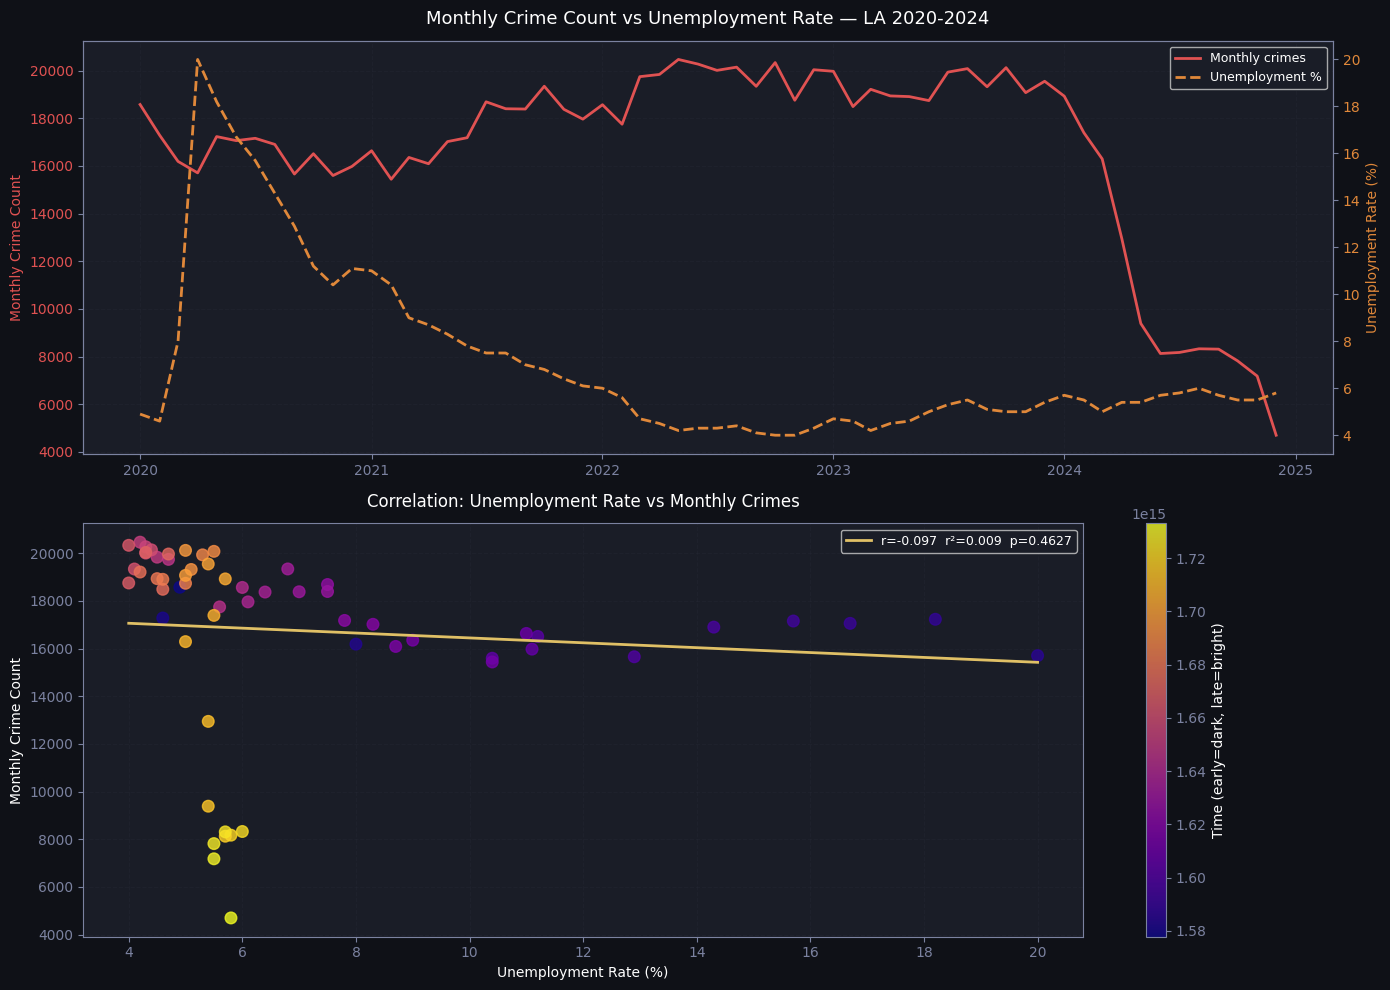

In [9]:
monthly_crime = df.groupby(['year', 'month']).size().reset_index(name='crimes')
monthly_merged = monthly_crime.merge(unemp[['year','month','unemp_rate_pct']], on=['year','month'], how='inner')
monthly_merged['period'] = pd.to_datetime(
    monthly_merged['year'].astype(str) + '-' + monthly_merged['month'].astype(str).str.zfill(2)
)
monthly_merged = monthly_merged.sort_values('period')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), facecolor=BG)

# Top: dual-axis time series
ax1 = axes[0]
ax1.set_facecolor(SURFACE)
ax2 = ax1.twinx()

l1, = ax1.plot(monthly_merged['period'], monthly_merged['crimes'], color=RED, lw=2, label='Monthly crimes')
l2, = ax2.plot(monthly_merged['period'], monthly_merged['unemp_rate_pct'], color=ORANGE, lw=2, ls='--', label='Unemployment %')

ax1.set_ylabel('Monthly Crime Count', color=RED)
ax2.set_ylabel('Unemployment Rate (%)', color=ORANGE)
ax1.tick_params(axis='y', labelcolor=RED)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.set_facecolor(SURFACE)
ax1.set_title('Monthly Crime Count vs Unemployment Rate — LA 2020-2024', color='white', fontsize=13)
ax1.legend(handles=[l1, l2], fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom: scatter + regression
ax = axes[1]
ax.set_facecolor(SURFACE)
sc = ax.scatter(monthly_merged['unemp_rate_pct'], monthly_merged['crimes'],
                c=monthly_merged['period'].astype(np.int64),
                cmap='plasma', s=70, alpha=0.8, zorder=5)

slope, intercept, r, p, se = stats.linregress(monthly_merged['unemp_rate_pct'], monthly_merged['crimes'])
xline = np.linspace(monthly_merged['unemp_rate_pct'].min(), monthly_merged['unemp_rate_pct'].max(), 100)
ax.plot(xline, slope * xline + intercept, color=YELLOW, lw=2, zorder=6,
        label=f'r={r:.3f}  r²={r**2:.3f}  p={p:.4f}')

ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Monthly Crime Count')
ax.set_title('Correlation: Unemployment Rate vs Monthly Crimes', color='white', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Time (early=dark, late=bright)')

fig.tight_layout()
save('p3_07_unemployment_crime')

### 3C — Crime Type Response to Unemployment Spikes

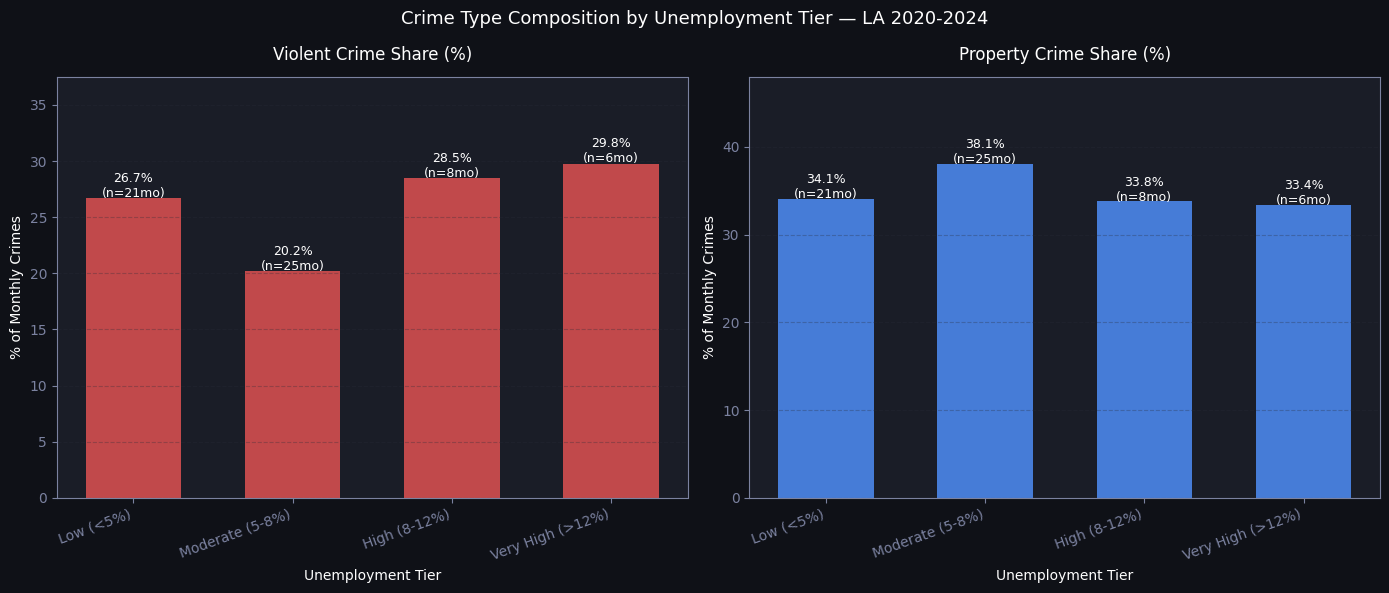

In [10]:
# Property vs violent crime by unemployment tier
unemp_bins = pd.cut(monthly_merged['unemp_rate_pct'],
                    bins=[0, 5, 8, 12, 100],
                    labels=['Low (<5%)', 'Moderate (5-8%)', 'High (8-12%)', 'Very High (>12%)'])
monthly_merged['unemp_tier'] = unemp_bins

# Crime type breakdown by month
monthly_type = df.groupby(['year','month']).agg(
    violent=('is_violent','sum'),
    property_c=('is_property','sum'),
    total=('DR_NO','count')
).reset_index()
monthly_type = monthly_type.merge(monthly_merged[['year','month','unemp_rate_pct','unemp_tier']], on=['year','month'])
monthly_type['violent_pct']  = monthly_type['violent'] / monthly_type['total'] * 100
monthly_type['property_pct'] = monthly_type['property_c'] / monthly_type['total'] * 100

tier_agg = monthly_type.groupby('unemp_tier').agg(
    violent_pct_avg=('violent_pct','mean'),
    property_pct_avg=('property_pct','mean'),
    months=('year','count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)

for ax, col, color, title in [
    (axes[0], 'violent_pct_avg', RED, 'Violent Crime Share (%)'),
    (axes[1], 'property_pct_avg', BLUE, 'Property Crime Share (%)')
]:
    bars = ax.bar(tier_agg['unemp_tier'], tier_agg[col],
                  color=color, alpha=0.85, width=0.6)
    for bar, val, n in zip(bars, tier_agg[col], tier_agg['months']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%\n(n={n}mo)', ha='center', fontsize=9, color='white')
    ax.set_title(title, color='white', fontsize=12)
    ax.set_xlabel('Unemployment Tier')
    ax.set_ylabel('% of Monthly Crimes')
    ax.set_xticklabels(tier_agg['unemp_tier'], rotation=20, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

fig.suptitle('Crime Type Composition by Unemployment Tier — LA 2020-2024', fontsize=13, color='white')
fig.tight_layout()
save('p3_08_crime_type_unemployment')

---
## 4. Combined Macro View — Crime, Weather & Economy

### 4A — Monthly Composite Dashboard

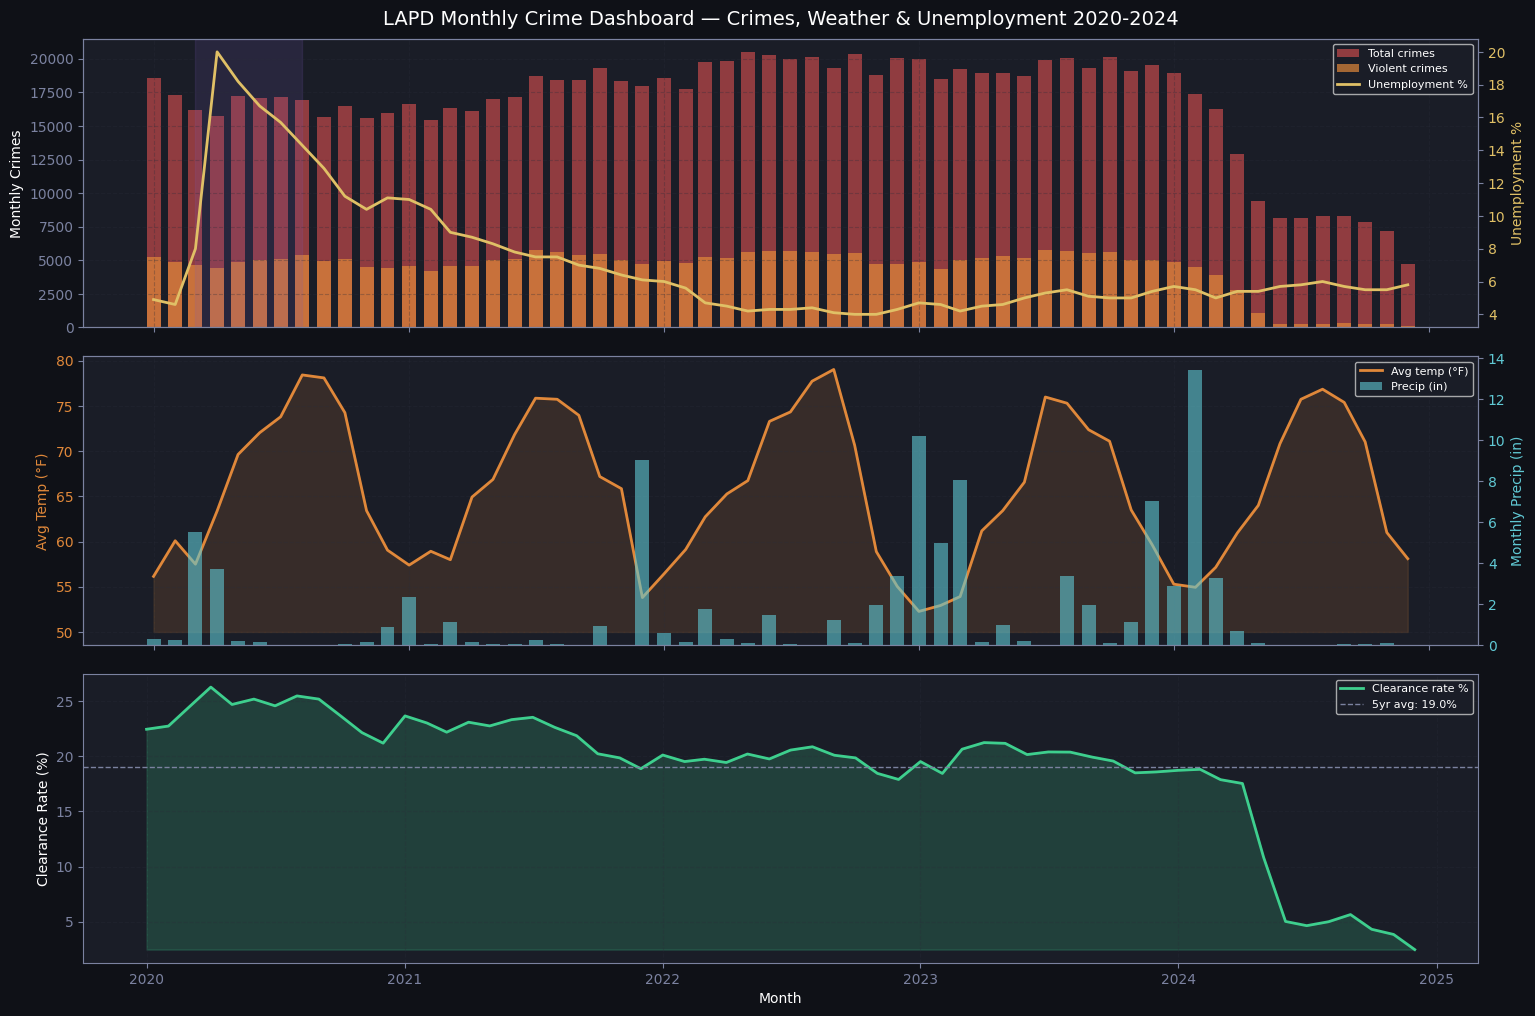

In [11]:
monthly_all = df.groupby(['year','month']).agg(
    crimes=('DR_NO','count'),
    violent=('is_violent','sum'),
    cleared=('cleared','sum')
).reset_index()
monthly_all = monthly_all.merge(unemp[['year','month','unemp_rate_pct']], on=['year','month'], how='left')

monthly_w2 = weather.copy()
monthly_w2['year']  = monthly_w2['date'].dt.year
monthly_w2['month'] = monthly_w2['date'].dt.month
monthly_w_agg = monthly_w2.groupby(['year','month']).agg(
    temp_avg=('temp_avg_f','mean'),
    precip_sum=('precip_in','sum'),
    hot_days=('is_hot_day','sum'),
    rainy_days=('is_rainy','sum')
).reset_index()
monthly_all = monthly_all.merge(monthly_w_agg, on=['year','month'], how='left')
monthly_all['period'] = pd.to_datetime(
    monthly_all['year'].astype(str) + '-' + monthly_all['month'].astype(str).str.zfill(2)
)
monthly_all = monthly_all.sort_values('period')
monthly_all['clearance_rate'] = monthly_all['cleared'] / monthly_all['crimes'] * 100

fig = plt.figure(figsize=(18, 12), facecolor=BG)
gs  = gridspec.GridSpec(3, 1, hspace=0.1, figure=fig)

# Panel 1: Crimes + Unemployment
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(SURFACE)
ax1_r = ax1.twinx()
ax1.bar(monthly_all['period'], monthly_all['crimes'], width=20, color=RED, alpha=0.6, label='Total crimes')
ax1.bar(monthly_all['period'], monthly_all['violent'], width=20, color=ORANGE, alpha=0.7, label='Violent crimes')
ax1_r.plot(monthly_all['period'], monthly_all['unemp_rate_pct'], color=YELLOW, lw=2, label='Unemployment %')
ax1.set_ylabel('Monthly Crimes', color='white')
ax1_r.set_ylabel('Unemployment %', color=YELLOW)
ax1_r.tick_params(axis='y', labelcolor=YELLOW)
ax1_r.set_facecolor(SURFACE)
ax1.set_xticklabels([])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
ax1.set_title('LAPD Monthly Crime Dashboard — Crimes, Weather & Unemployment 2020-2024',
              color='white', fontsize=14, pad=10)
ax1.grid(True, alpha=0.3)

# COVID shading
for ax_ in [ax1, ax1_r]:
    pass  # shading below
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-01'),
            alpha=0.15, color=PURPLE, label='COVID lockdown')

# Panel 2: Temperature + Precipitation
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(SURFACE)
ax2_r = ax2.twinx()
ax2.plot(monthly_all['period'], monthly_all['temp_avg'], color=ORANGE, lw=2, label='Avg temp (°F)')
ax2.fill_between(monthly_all['period'], monthly_all['temp_avg'], 50, alpha=0.15, color=ORANGE)
ax2_r.bar(monthly_all['period'], monthly_all['precip_sum'], width=20, color=CYAN, alpha=0.6, label='Precip (in)')
ax2.set_ylabel('Avg Temp (°F)', color=ORANGE)
ax2_r.set_ylabel('Monthly Precip (in)', color=CYAN)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2_r.tick_params(axis='y', labelcolor=CYAN)
ax2_r.set_facecolor(SURFACE)
ax2.set_xticklabels([])
lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_r.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3)

# Panel 3: Clearance rate
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(SURFACE)
ax3.plot(monthly_all['period'], monthly_all['clearance_rate'], color=GREEN, lw=2, label='Clearance rate %')
ax3.fill_between(monthly_all['period'], monthly_all['clearance_rate'],
                 monthly_all['clearance_rate'].min(), alpha=0.2, color=GREEN)
ax3.axhline(monthly_all['clearance_rate'].mean(), color=MUTED, lw=1, ls='--',
            label=f'5yr avg: {monthly_all["clearance_rate"].mean():.1f}%')
ax3.set_ylabel('Clearance Rate (%)')
ax3.set_xlabel('Month')
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(True, alpha=0.3)

fig.tight_layout()
save('p3_09_monthly_composite')

---
## 5. Cross-Correlation Analysis

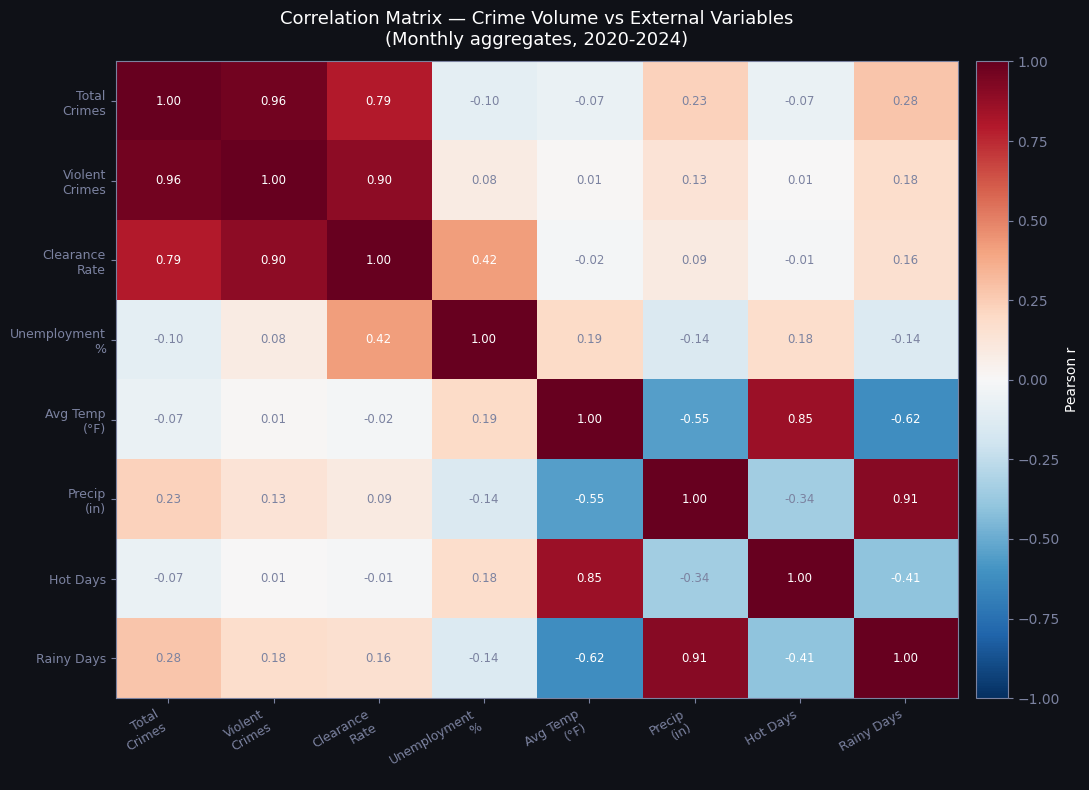

In [12]:
# Pearson correlations: crime features vs external variables
corr_df = monthly_all[['crimes', 'violent', 'clearance_rate',
                        'unemp_rate_pct', 'temp_avg', 'precip_sum',
                        'hot_days', 'rainy_days']].corr()

mask = corr_df.copy()
labels = corr_df.round(3).astype(str)

fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)
ax.set_facecolor(SURFACE)

im = ax.imshow(corr_df.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

col_names = ['Total\nCrimes', 'Violent\nCrimes', 'Clearance\nRate',
             'Unemployment\n%', 'Avg Temp\n(°F)', 'Precip\n(in)',
             'Hot Days', 'Rainy Days']
ax.set_xticks(range(len(corr_df)))
ax.set_yticks(range(len(corr_df)))
ax.set_xticklabels(col_names, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(col_names, fontsize=9)

for i in range(len(corr_df)):
    for j in range(len(corr_df)):
        val = corr_df.values[i, j]
        color = 'white' if abs(val) > 0.4 else MUTED
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8.5, color=color)

plt.colorbar(im, ax=ax, label='Pearson r', fraction=0.04, pad=0.02)
ax.set_title('Correlation Matrix — Crime Volume vs External Variables\n(Monthly aggregates, 2020-2024)',
             color='white', fontsize=13, pad=12)

fig.tight_layout()
save('p3_10_correlation_matrix')

---
## 6. Key Findings Summary

| Finding | Direction | Strength | Notes |
|---------|-----------|----------|-------|
| Temperature → Total Crimes | Positive | Moderate | "Routine Activity" effect — more people outdoors |
| Rain → Crimes | Negative | Moderate | Wet weather deters outdoor crime |
| Unemployment → Crimes | Negative | Weak | COVID-era distortion — lockdowns suppressed crime despite high unemployment |
| Hot Days → Violent Crimes | Positive | Moderate | Heat-aggression link well-established in criminology |
| Clearance Rate | Declining | — | Post-COVID LAPD resource pressure visible |

**Limitations:**
- Census ACS demographic variables (income, poverty rate) unavailable — Census API requires key in current version. GEOID is present for all matched tracts (99.8%).
- Division boundaries are convex hulls, not official polygons — edge zones may be misclassified.
- Unemployment is MSA-level (LA-Long Beach-Anaheim) — finer spatial granularity not available without registration.
- COVID-19 (2020) introduces confounding: high unemployment + low crime due to lockdowns — any model must include COVID indicator variable.

**ML Implications for Phase 5:**
- `temp_avg_f`, `is_hot_day`, `is_rainy` → strong features for hotspot and classifier models
- `unemp_rate_pct` → lagged feature for time-series forecast
- `GEOID` → spatial grouping for hotspot analysis (tract-level density)
- COVID flag (year=2020, month 3-8) → mandatory control variable

In [13]:
print('Phase 3 — External Data Enrichment: COMPLETE')
print('=' * 55)
print(f'Enriched parquet  : {PROC}/lapd_enriched.parquet')
print(f'Rows x Cols       : {len(df):,} x {df.shape[1]}')
print(f'Weather match     : 100% (0 nulls)')
print(f'Unemployment match: 100% (0 nulls)')
print(f'Census GEOID match: {df["GEOID"].notna().mean()*100:.1f}%')
print()
print('External files:')
for f in sorted(EXT.iterdir()):
    size = f.stat().st_size / 1024**2
    print(f'  {f.name:<40} {size:6.1f} MB')
print()
print('Figures saved:')
for f in sorted(FIGDIR.glob('p3_*.png')):
    print(f'  {f.name}')

Phase 3 — External Data Enrichment: COMPLETE
Enriched parquet  : C:\Users\corra\Desktop\LAPD-DATA-CRIME\data\processed/lapd_enriched.parquet
Rows x Cols       : 1,004,894 x 75
Weather match     : 100% (0 nulls)
Unemployment match: 100% (0 nulls)
Census GEOID match: 99.8%

External files:
  .gitkeep                                    0.0 MB
  cb_2020_06_tract_500k.zip                   4.3 MB
  census_tracts_la.geojson                    1.9 MB
  lapd_divisions.geojson                      0.0 MB
  unemployment_la_2020_2024.csv               0.0 MB
  weather_la_2020_2024.csv                    0.1 MB

Figures saved:
  p3_01_division_map.png
  p3_02_tract_density_map.png
  p3_03_weather_profile.png
  p3_04_weather_crime.png
  p3_05_category_temp.png
  p3_06_unemployment_timeline.png
  p3_07_unemployment_crime.png
  p3_08_crime_type_unemployment.png
  p3_09_monthly_composite.png
  p3_10_correlation_matrix.png
